# Fine-tuning Qwen 3.5 27B
Can parameter count fix all my problems?

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["HF_HUB_OFFLINE"] = "1"

from dotenv import load_dotenv
load_dotenv()
SYSTEM_PROMPT = os.getenv("SYSTEM_PROMPT") 

import torch
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

from evaluation import formatting_func

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Model + Data Prep

In [2]:
max_seq_length = 2048
model_name = "eb-qwen-27b-lora-522"

model, tokenizer= FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3.5-27B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/1184 [00:00<?, ?it/s]

In [3]:
train_path = "../data/echobot_old/train.jsonl"
val_path = "../data/echobot_old/val.jsonl"
test_path = "../data/echobot_old/test.jsonl"

dataset = load_dataset(
    "json",
    data_files={
        "train": train_path,
        "validation": val_path,
        "test": test_path,
    },
)
dataset["train"] = dataset["train"].shuffle(seed=8)
print(dataset['train'].features)

{'id': Value('string'), 'query': Value('string'), 'label': Value('int64'), 'source': Value('string'), 'tag': Value('string')}


In [4]:
from collections import Counter

# format dataset with only 'prompt' and 'completion' collumns
formatted_train = dataset["train"].map(
    formatting_func,
    remove_columns=dataset["train"].column_names
    )
formatted_val = dataset["validation"].map(
    formatting_func,
    remove_columns=dataset["validation"].column_names
    )
formatted_test = dataset["test"].map(
    formatting_func,
    remove_columns=dataset["test"].column_names
    )

print(Counter(formatted_train["completion"]))
print(Counter(formatted_val["completion"]))
print(Counter(formatted_test["completion"]))


Counter({'0': 254, '1': 250})
Counter({'0': 8, '1': 8})
Counter({'0': 42, '1': 36})


In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 10,
    lora_alpha = 20,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        # "gate_proj", "up_proj", "down_proj",
    ],

    finetune_vision_layers = False,
    finetune_language_layers = True, 
    finetune_attention_modules = True,
    finetune_mlp_modules = True,

    lora_dropout = 0.10,
    bias = "none",
    use_gradient_checkpointing = "unsloth",

    random_state = 8,
    max_seq_length = max_seq_length,
)

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


## Training

In [6]:
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_train,
    eval_dataset=formatted_val,
    processing_class=tokenizer,

    args=SFTConfig(
        max_seq_length=max_seq_length,
        completion_only_loss=True,
        per_device_train_batch_size=8,

        eval_strategy="steps",
        gradient_accumulation_steps=4,
        warmup_ratio=0.05,
        num_train_epochs=3,
        optim="adamw_8bit",

        seed=8,
        dataset_num_proc=1,

        output_dir=f"../checkpoints/{model_name}",
        logging_steps=1,
    ),
)
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["prompt"+"completion"]:   0%|          | 0/504 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["prompt"+"completion"]:   0%|          | 0/16 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 504 | Num Epochs = 3 | Total steps = 48
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 6,553,600 of 27,363,282,160 (0.02% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
1,2.989908,3.211535
2,3.004964,3.219542
3,3.037131,3.188888
4,3.004085,3.105163
5,2.909297,2.940821
6,2.765566,2.771025
7,2.638099,2.472562
8,2.271900,2.214565
9,2.128978,2.010052
10,1.871818,1.772265


Filter:   0%|          | 0/16 [00:00<?, ? examples/s]

/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in unsloth/Qwen3.5-27B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in ../checkpoints/eb-qwen-27b-lora-522/checkpoint-48/tokenizer_config.json.


TrainOutput(global_step=48, training_loss=0.8339446073708435, metrics={'train_runtime': 366.2818, 'train_samples_per_second': 4.128, 'train_steps_per_second': 0.131, 'total_flos': 2.9333477425250304e+16, 'train_loss': 0.8339446073708435, 'epoch': 3.0})

## Evaluation

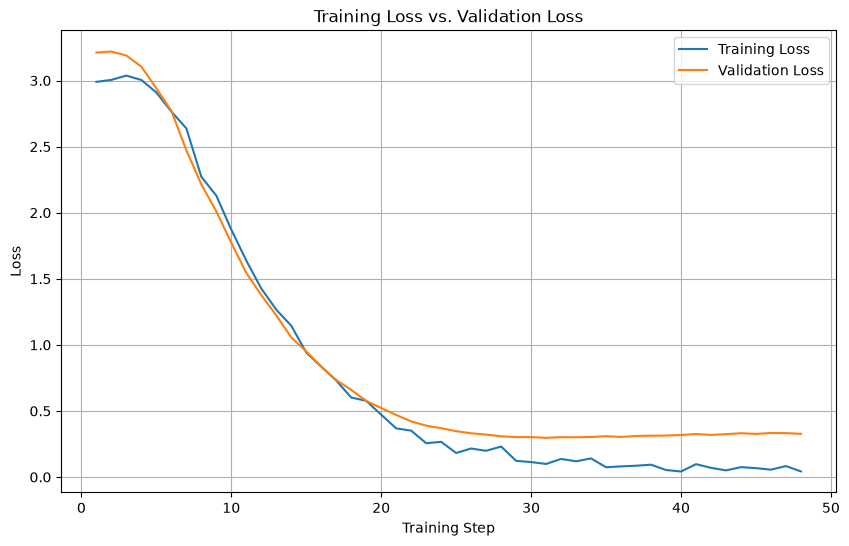

Accuracy: 71/78 = 0.9103
TPR (recall): 0.8611
FPR: 0.0476
Precision: 0.9394


In [7]:
from evaluation import (
    evaluate_model, 
    plot_loss
)
plot_loss(trainer=trainer, show_val=True)

evaluate_model(
    model=model, 
    tokenizer=tokenizer,
    dataset=dataset['test'],
    model_str=model_name,
    batch_size=16
)

# Save model adapters to disk 

In [ ]:
adapter_path = f"../adapters/{model_name}"

model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"Saved LoRA adapter to {adapter_path}")